In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print(f"Training set: {x_train.shape}")
print(f"Test set: {x_test.shape}")
print(f"Classes: {np.unique(y_train)}")

Training set: (50000, 32, 32, 3)
Test set: (10000, 32, 32, 3)
Classes: [0 1 2 3 4 5 6 7 8 9]


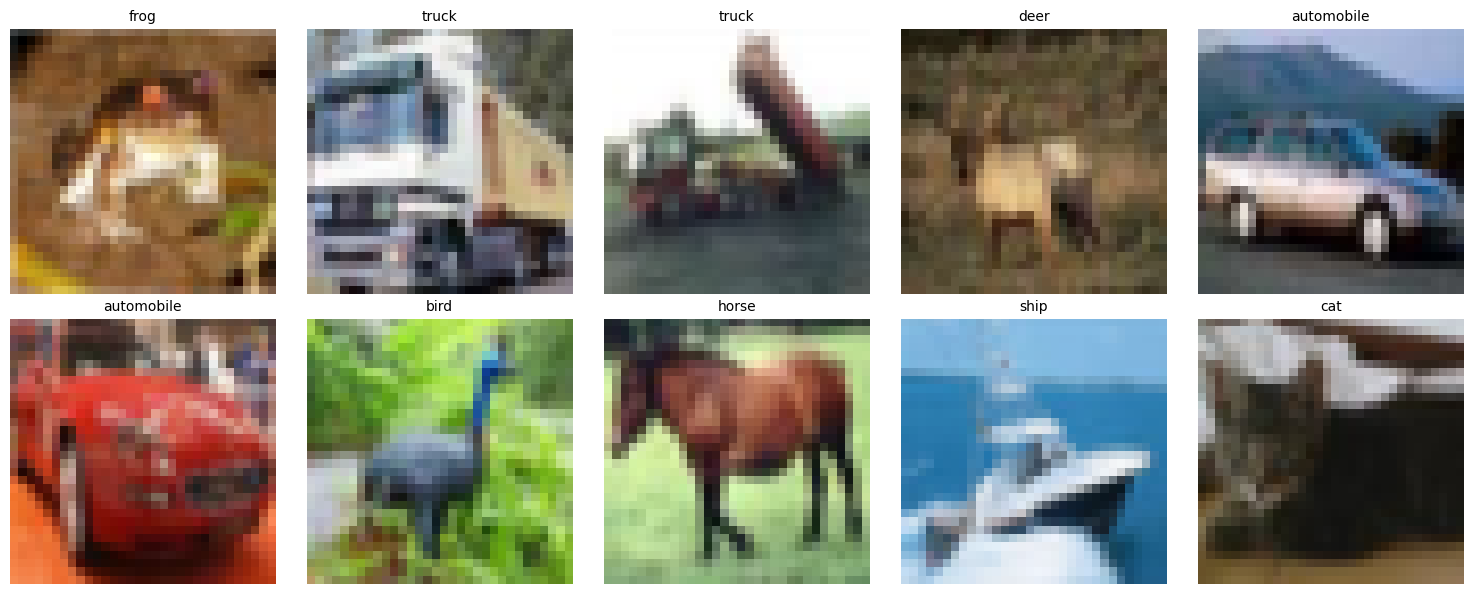

In [9]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']


fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(10):
    row, col = i // 5, i % 5
    axes[row, col].imshow(x_train[i])
    axes[row, col].set_title(f'{class_names[y_train[i][0]]}', fontsize=10)
    axes[row, col].axis('off')
plt.tight_layout()
plt.show()

**Data Preprocessing**

In [10]:
# Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"Data range: [{x_train.min():.2f}, {x_train.max():.2f}]")

Data range: [0.00, 1.00]


**Build CNN Model**

In [11]:
model = keras.Sequential([
    # Data augmentation
    layers.RandomRotation(0.1, input_shape=(32, 32, 3)),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomFlip('horizontal'),
    
    # Convolutional blocks
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Dropout(0.25),
    
    # Classifier
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,190,314 (4.54 MB)

 Trainable params: 1,189,866 (4.54 MB)

 Non-trainable params: 448 (1.75 KB)

**Train with Data Augmentation**

In [13]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    keras.callbacks.ModelCheckpoint('best_cifar10.h5', save_best_only=True),
    keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, cooldown=1)
]

history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=50,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1669 - loss: 2.5085

313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - accuracy: 0.1671 - loss: 2.5075 - val_accuracy: 0.1188 - val_loss: 3.4198 - learning_rate: 1.0000e-04
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3071 - loss: 1.9167

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.3071 - loss: 1.9166 - val_accuracy: 0.3902 - val_loss: 1.6720 - learning_rate: 1.0000e-04
Epoch 3/50
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3529 - loss: 1.8006

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.3530 - loss: 1.8004 - val_accuracy: 0.4630 - val_loss: 1.4902 - learning_rate: 1.0000e-04
Epoch 4/50
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3782 - loss: 1.7200

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.3783 - loss: 1.7199 - val_accuracy: 0.4697 - val_loss: 1.4566 - learning_rate: 1.0000e-04
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.4030 - loss: 1.6635 - val_accuracy: 0.4782 - val_loss: 1.4699 - learning_rate: 1.0000e-04
Epoch 6/50
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4164 - loss: 1.6230

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.4165 - loss: 1.6228 - val_accuracy: 0.5160 - val_loss: 1.3797 - learning_rate: 1.0000e-04
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.4338 - loss: 1.5736 - val_accuracy: 0.4857 - val_loss: 1.5363 - learning_rate: 1.0000e-04
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.4439 - loss: 1.5511 - val_accuracy: 0.4729 - val_loss: 1.6744 - learning_rate: 1.0000e-04
Epoch 9/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.4587 - loss: 1.5079 - val_accuracy: 0.4980 - val_loss: 1.5672 - learning_rate: 1.0000e-04
Epoch 10/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.4734 - loss: 1.4672 - val_accuracy: 0.5098 - val_loss: 1.4634 - learning_rate: 5.0000e-05
Epoch 11/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.4892 - loss: 1.4376 - val_accuracy: 0.5016 - val_loss: 1.5784 - learning_rate: 5.0000e-05


In [14]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5135 - loss: 1.3716
Test accuracy: 0.5113


**Transfer Learning**

In [15]:
from tensorflow.keras.applications import ResNet50

In [16]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(32, 32, 3)
)

base_model.trainable = False

In [17]:
transfer_model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

transfer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 1, 1, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,851,274 (90.99 MB)

 Trainable params: 263,562 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [18]:
transfer_model.fit(x_train, y_train, batch_size=128, epochs=10, validation_split=0.2)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.1025 - loss: 2.3890 - val_accuracy: 0.1415 - val_loss: 2.2584
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.1266 - loss: 2.2612 - val_accuracy: 0.1595 - val_loss: 2.2117
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.1285 - loss: 2.2479 - val_accuracy: 0.1621 - val_loss: 2.2076
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.1282 - loss: 2.2418 - val_accuracy: 0.1545 - val_loss: 2.2060
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.1325 - loss: 2.2390 - val_accuracy: 0.1566 - val_loss: 2.1935
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.1304 - loss: 2.2352 - val_accuracy: 0.1676 - val_loss: 2.1699
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.1334 - loss: 2.2373 - val_accuracy: 0.1691 - val_loss: 2.1699
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.1322 - loss: 2.2353 - val_acc

**CNN Model without Data Augmentation**

In [23]:
model_custom = keras.Sequential([
    layers.Input(shape=(32, 32, 3)), 
    
    # Convolutional blocks
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Classifier
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [24]:
model_custom.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_custom.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 392,010 (1.50 MB)

 Trainable params: 391,562 (1.49 MB)

 Non-trainable params: 448 (1.75 KB)

In [25]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    keras.callbacks.ModelCheckpoint('best_cifar10.h5', save_best_only=True),
]

history = model_custom.fit(
    x_train, y_train,
    batch_size=128,
    epochs=50,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1835 - loss: 2.2883

313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - accuracy: 0.1836 - loss: 2.2877 - val_accuracy: 0.1585 - val_loss: 5.2500
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3239 - loss: 1.8103

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3240 - loss: 1.8100 - val_accuracy: 0.4106 - val_loss: 1.5748
Epoch 3/50
307/313 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4215 - loss: 1.5595

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4219 - loss: 1.5586 - val_accuracy: 0.4979 - val_loss: 1.4471
Epoch 4/50
309/313 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4910 - loss: 1.3918

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.4911 - loss: 1.3915 - val_accuracy: 0.5777 - val_loss: 1.2449
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5337 - loss: 1.2902 - val_accuracy: 0.5660 - val_loss: 1.3239
Epoch 6/50
307/313 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5699 - loss: 1.2020

...

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7546 - loss: 0.7217 - val_accuracy: 0.7335 - val_loss: 0.7800
Epoch 26/50
307/313 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7572 - loss: 0.7121

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7572 - loss: 0.7123 - val_accuracy: 0.7629 - val_loss: 0.7343
Epoch 27/50
308/313 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7670 - loss: 0.6912

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7670 - loss: 0.6913 - val_accuracy: 0.7544 - val_loss: 0.7189
Epoch 28/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7664 - loss: 0.6992 - val_accuracy: 0.7027 - val_loss: 0.8740
Epoch 29/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7677 - loss: 0.6778 - val_accuracy: 0.7331 - val_loss: 0.7781
Epoch 30/50
307/313 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7702 - loss: 0.6754

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7702 - loss: 0.6753 - val_accuracy: 0.7675 - val_loss: 0.6988
Epoch 31/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7763 - loss: 0.6622 - val_accuracy: 0.7614 - val_loss: 0.7030
Epoch 32/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7766 - loss: 0.6596 - val_accuracy: 0.7498 - val_loss: 0.7254
Epoch 33/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7801 - loss: 0.6513 - val_accuracy: 0.7339 - val_loss: 0.7570
Epoch 34/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7801 - loss: 0.6421 - val_accuracy: 0.7431 - val_loss: 0.7385
Epoch 35/50
308/313 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7853 - loss: 0.6342

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7853 - loss: 0.6345 - val_accuracy: 0.7872 - val_loss: 0.6503
Epoch 36/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7868 - loss: 0.6302 - val_accuracy: 0.7467 - val_loss: 0.7410
Epoch 37/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7882 - loss: 0.6248 - val_accuracy: 0.7755 - val_loss: 0.6752
Epoch 38/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7921 - loss: 0.6170 - val_accuracy: 0.7331 - val_loss: 0.7931
Epoch 39/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7883 - loss: 0.6270 - val_accuracy: 0.7592 - val_loss: 0.7048
Epoch 40/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7912 - loss: 0.6104 - val_accuracy: 0.7707 - val_loss: 0.6781


In [26]:
# Evaluate
test_loss, test_acc = model_custom.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7811 - loss: 0.6726
Test accuracy: 0.7818


**Evaluate and Improve**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step


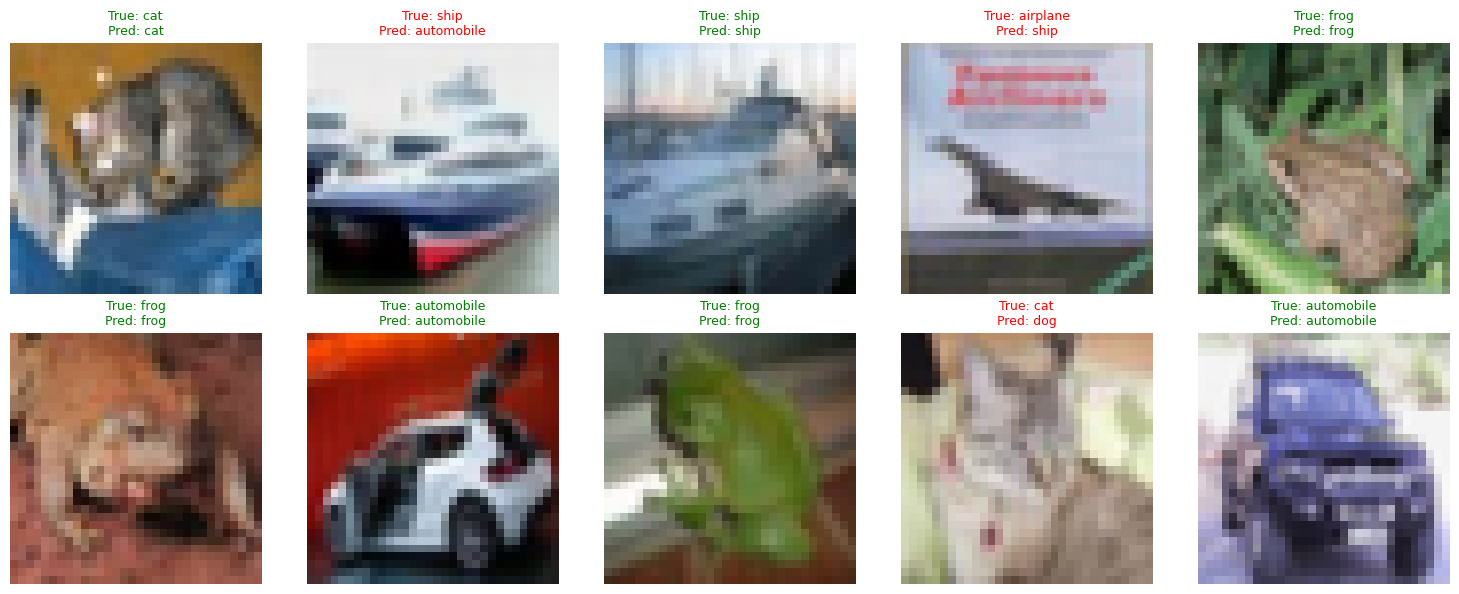

In [27]:
# Make predictions
predictions = model.predict(x_test[:10])
predicted_classes = np.argmax(predictions, axis=1)


# Visualize predictions
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(10):
    row, col = i // 5, i % 5
    axes[row, col].imshow(x_test[i])
    true_label = class_names[y_test[i][0]]
    pred_label = class_names[predicted_classes[i]]
    color = 'green' if true_label == pred_label else 'red'
    axes[row, col].set_title(f'True: {true_label}\nPred: {pred_label}', 
                            fontsize=9, color=color)
    axes[row, col].axis('off')
plt.tight_layout()
plt.show()